### All days of the challange:

* [Day 1: Handling missing values](https://www.kaggle.com/rtatman/data-cleaning-challenge-handling-missing-values)
* [Day 2: Scaling and normalization](https://www.kaggle.com/rtatman/data-cleaning-challenge-scale-and-normalize-data)
* [Day 3: Parsing dates](https://www.kaggle.com/rtatman/data-cleaning-challenge-parsing-dates/)
* [Day 4: Character encodings](https://www.kaggle.com/rtatman/data-cleaning-challenge-character-encodings/)
* [Day 5: Inconsistent Data Entry](https://www.kaggle.com/rtatman/data-cleaning-challenge-inconsistent-data-entry/)
___
Welcome to day 3 of the 5-Day Data Challenge! Today, we're going to work with dates. To get started, click the blue "Fork Notebook" button in the upper, right hand corner. This will create a private copy of this notebook that you can edit and play with. Once you're finished with the exercises, you can choose to make your notebook public to share with others. :)

> **Your turn!** As we work through this notebook, you'll see some notebook cells (a block of either code or text) that has "Your Turn!" written in it. These are exercises for you to do to help cement your understanding of the concepts we're talking about. Once you've written the code to answer a specific question, you can run the code by clicking inside the cell (box with code in it) with the code you want to run and then hit CTRL + ENTER (CMD + ENTER on a Mac). You can also click in a cell and then click on the right "play" arrow to the left of the code. If you want to run all the code in your notebook, you can use the double, "fast forward" arrows at the bottom of the notebook editor.

Here's what we're going to do today:

* [Get our environment set up](#Get-our-environment-set-up)
* [Check the data type of our date column](#Check-the-data-type-of-our-date-column)
* [Convert our date columns to datetime](#Convert-our-date-columns-to-datetime)
* [Select just the day of the month from our column](#Select-just-the-day-of-the-month-from-our-column)
* [Plot the day of the month to check the date parsing](#Plot-the-day-of-the-month-to-the-date-parsing)

Let's get started!

# Get our environment set up
________

The first thing we'll need to do is load in the libraries and datasets we'll be using. For today, we'll be working with two datasets: one containing information on earthquakes that occured between 1965 and 2016, and another that contains information on landslides that occured between 2007 and 2016.

> **Important!** Make sure you run this cell yourself or the rest of your code won't work!

In [20]:
# modules we'll use
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

# read in our data
earthquakes = pd.read_csv("../input/earthquake-database/database.csv")
landslides = pd.read_csv("../input/landslide-events/catalog.csv")
volcanos = pd.read_csv("../input/volcanic-eruptions/database.csv")

# set seed for reproducibility
np.random.seed(0)

Now we're ready to look at some dates! (If you like, you can take this opportunity to take a look at some of the data.)

# Check the data type of our date column
___

For this part of the challenge, I'll be working with the `date` column from the `landslides` dataframe. The very first thing I'm going to do is take a peek at the first few rows to make sure it actually looks like it contains dates.

In [21]:
# print the first few rows of the date column
print(landslides['date'].head())

0     3/2/07
1    3/22/07
2     4/6/07
3    4/14/07
4    4/15/07
Name: date, dtype: object


Yep, those are dates! But just because I, a human, can tell that these are dates doesn't mean that Python knows that they're dates. Notice that the at the bottom of the output of `head()`, you can see that it says that the data type of this  column is "object". 

> Pandas uses the "object" dtype for storing various types of data types, but most often when you see a column with the dtype "object" it will have strings in it. 

If you check the pandas dtype documentation [here](http://pandas.pydata.org/pandas-docs/stable/basics.html#dtypes), you'll notice that there's also a specific `datetime64` dtypes. Because the dtype of our column is `object` rather than `datetime64`, we can tell that Python doesn't know that this column contains dates.

We can also look at just the dtype of your column without printing the first few rows if we like:

In [22]:
# check the data type of our date column
landslides['date'].dtype

dtype('O')

You may have to check the [numpy documentation](https://docs.scipy.org/doc/numpy-1.12.0/reference/generated/numpy.dtype.kind.html#numpy.dtype.kind) to match the letter code to the dtype of the object. "O" is the code for "object", so we can see that these two methods give us the same information.

In [23]:
# Your turn! Check the data type of the Date column in the earthquakes dataframe
# (note the capital 'D' in date!)
print(earthquakes['Date'].head())
print(f"\nType de la colonne Date : {earthquakes['Date'].dtype}")

0    01/02/1965
1    01/04/1965
2    01/05/1965
3    01/08/1965
4    01/09/1965
Name: Date, dtype: object

Type de la colonne Date : object


**Réponse :** la colonne `Date` est de type `object` (code NumPy `'O'`) : pandas y stocke des **chaînes de caractères** comme `"01/02/1965"`, et non des dates. Tant qu'elle n'est pas convertie, aucune opération calendaire n'est possible : extraire le jour, comparer deux dates, calculer une durée, regrouper par mois…

# Convert our date columns to datetime
___

Now that we know that our date column isn't being recognized as a date, it's time to convert it so that it *is* recognized as a date. This is called "parsing dates" because we're taking in a string and identifying its component parts.

We can pandas what the format of our dates are with a guide called as ["strftime directive", which you can find more information on at this link](http://strftime.org/). The basic idea is that you need to point out which parts of the date are where and what punctuation is between them. There are [lots of possible parts of a date](http://strftime.org/), but the most common are `%d` for day, `%m` for month, `%y` for a two-digit year and `%Y` for a four digit year.

Some examples:

 * 1/17/07 has the format "%m/%d/%y"
 * 17-1-2007 has the format "%d-%m-%Y"
 
 Looking back up at the head of the `date` column in the landslides dataset, we can see that it's in the format "month/day/two-digit year", so we can use the same syntax as the first example to parse in our dates: 

In [24]:
# create a new column, date_parsed, with the parsed dates
landslides['date_parsed'] = pd.to_datetime(landslides['date'], format = "%m/%d/%y")

Now when I check the first few rows of the new column, I can see that the dtype is `datetime64`. I can also see that my dates have been slightly rearranged so that they fit the default order datetime objects (year-month-day).

In [25]:
# print the first few rows
landslides['date_parsed'].head()

0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: date_parsed, dtype: datetime64[ns]

Now that our dates are parsed correctly, we can interact with them in useful ways.

___
* **What if I run into an error with multiple date formats?** While we're specifying the date format here, sometimes you'll run into an error when there are multiple date formats in a single column. If that happens, you have have pandas try to infer what the right date format should be. You can do that like so:

`landslides['date_parsed'] = pd.to_datetime(landslides['Date'], infer_datetime_format=True)`

* **Why don't you always use `infer_datetime_format = True?`** There are two big reasons not to always have pandas guess the time format. The first is that pandas won't always been able to figure out the correct date format, especially if someone has gotten creative with data entry. The second is that it's much slower than specifying the exact format of the dates.
____

In [26]:
# Your turn! Create a new column, date_parsed, in the earthquakes
# dataset that has correctly parsed dates in it. (Don't forget to 
# double-check that the dtype is correct!)
dates = earthquakes['Date']

# Format majoritaire : mois/jour/année sur 4 chiffres ; les dates non conformes deviennent NaT
parsed_mdy = pd.to_datetime(dates, format="%m/%d/%Y", errors='coerce')

# On affiche les lignes qui ne respectent pas ce format, plutôt que de les deviner
anomalies = dates[parsed_mdy.isnull()]
print(f"Dates au format inattendu : {len(anomalies)}")
print(anomalies)

# Ces lignes sont au format ISO 8601 (AAAA-MM-JJTHH:MM:SS…) : on garde les 10 premiers caractères
parsed_iso = pd.to_datetime(anomalies.str[:10], format="%Y-%m-%d", errors='coerce')
earthquakes['date_parsed'] = parsed_mdy.fillna(parsed_iso)

# Vérifications
print(f"\nType de date_parsed : {earthquakes['date_parsed'].dtype}")
print(f"Dates non converties restantes : {earthquakes['date_parsed'].isnull().sum()}")
print(f"Plage : {earthquakes['date_parsed'].min().date()} → {earthquakes['date_parsed'].max().date()}")
earthquakes['date_parsed'].head()

Dates au format inattendu : 3
3378     1975-02-23T02:58:41.000Z
7512     1985-04-28T02:53:41.530Z
20650    2011-03-13T02:23:34.520Z
Name: Date, dtype: object

Type de date_parsed : datetime64[ns]
Dates non converties restantes : 0
Plage : 1965-01-02 → 2016-12-30


0   1965-01-02
1   1965-01-04
2   1965-01-05
3   1965-01-08
4   1965-01-09
Name: date_parsed, dtype: datetime64[ns]

**Réponse :** la colonne `Date` mélange **deux formats** :
- presque toutes les lignes suivent `MM/JJ/AAAA`, soit `"%m/%d/%Y"` ;
- **3 lignes** (indices 3378, 7512 et 20650) sont au format **ISO 8601** complet, par exemple `1975-02-23T02:58:41.000Z` : date et heure en temps universel, le `Z` (« Zulu ») désignant UTC. Leur origine ne peut pas être déterminée à partir de ce seul fichier.

**Méthode.** On impose le format majoritaire avec `errors='coerce'`. Les lignes non conformes deviennent alors `NaT` au lieu de faire planter la conversion, ce qui permet de les **isoler et de les examiner**. On les convertit ensuite avec leur propre format. Résultat : type `datetime64[ns]`, **0 date non convertie**, plage du 1965-01-02 au 2016-12-30, cohérente avec la période annoncée (1965–2016).

**Pourquoi ne pas utiliser `infer_datetime_format=True` ?** Une chaîne comme `01/02/1965` admet deux lectures dès que le jour et le mois valent tous deux au plus 12 : le 2 janvier ou le 1er février. Une inférence automatique peut choisir la mauvaise **sans aucune erreur**. Un format explicite rend l'hypothèse visible et vérifiable. L'histogramme des jours du mois sert justement de contrôle : si jour et mois étaient inversés, aucun « jour » ne dépasserait 12.

**Pour aller plus loin : limites de `datetime64[ns]`.** Pandas stocke chaque date comme un entier signé sur 64 bits, compté en nanosecondes depuis le 1er janvier 1970. L'intervalle représentable est donc d'environ
$$\pm\frac{2^{63}\ \text{ns}}{3{,}156 \times 10^{16}\ \text{ns/an}} \approx \pm 292\ \text{ans},$$
soit des dates comprises entre **1677 et 2262**. C'est sans conséquence ici, mais cela devient décisif pour les éruptions volcaniques (voir le bonus en fin de notebook).

# Select just the day of the month from our column
___

"Ok, Rachael," you may be saying at this point, "This messing around with data types is fine, I guess, but what's the *point*?" To answer your question, let's try to get information on the day of the month that a landslide occured on from the original "date" column, which has an "object" dtype: 

In [27]:
# try to get the day of the month from the date column
try:
    day_of_month_landslides = landslides['date'].dt.day
except AttributeError as err:
    # Erreur attendue : la colonne « date » contient des chaînes, pas des dates
    print(f"AttributeError (attendue) : {err}")

AttributeError (attendue) : Can only use .dt accessor with datetimelike values


**Remarque :** la cellule d'origine provoque volontairement une `AttributeError` pour montrer que l'accesseur `.dt` exige une colonne de type date. Elle est ici encadrée par un bloc `try / except` : l'erreur reste visible, mais elle n'interrompt plus l'exécution complète du notebook.

We got an error! The important part to look at here is the part at the very end that says `AttributeError: Can only use .dt accessor with datetimelike values`. We're getting this error because the dt.day() function doesn't know how to deal with a column with the dtype "object". Even though our dataframe has dates in it, because they haven't been parsed we can't interact with them in a useful way.

Luckily, we have a column that we parsed earlier , and that lets us get the day of the month out no problem:

In [28]:
# get the day of the month from the date_parsed column
day_of_month_landslides = landslides['date_parsed'].dt.day

In [29]:
# Your turn! get the day of the month from the date_parsed column
day_of_month_earthquakes = earthquakes['date_parsed'].dt.day

# Vérification : les valeurs doivent être comprises entre 1 et 31
print(f"Jour minimal : {day_of_month_earthquakes.min():.0f} ; jour maximal : {day_of_month_earthquakes.max():.0f}")
print(f"Valeurs manquantes : {day_of_month_earthquakes.isnull().sum()}")

Jour minimal : 1 ; jour maximal : 31
Valeurs manquantes : 0


**Réponse :** les jours extraits vont de **1 à 31**, sans aucune valeur manquante. La présence de valeurs supérieures à 12 exclut une **inversion globale** jour/mois. Elle ne suffit toutefois pas à valider individuellement les dates ambiguës (`01/02`, `03/04`, etc.) ni à exclure un fichier qui mélangerait plusieurs conventions.

# Plot the day of the month to check the date parsing
___

One of the biggest dangers in parsing dates is mixing up the months and days. The to_datetime() function does have very helpful error messages, but it doesn't hurt to double-check that the days of the month we've extracted make sense. 

To do this, let's plot a histogram of the days of the month. We expect it to have values between 1 and 31 and, since there's no reason to suppose the landslides are more common on some days of the month than others, a relatively even distribution. (With a dip on 31 because not all months have 31 days.) Let's see if that's the case:

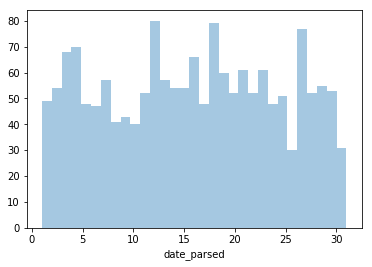

In [30]:
# remove na's
day_of_month_landslides = day_of_month_landslides.dropna()

# plot the day of the month
sns.distplot(day_of_month_landslides, kde=False, bins=31)

Yep, it looks like we did parse our dates correctly & this graph makes good sense to me. Why don't you take a turn checking the dates you parsed earlier?

Text(0,0.5,'Nombre de séismes')

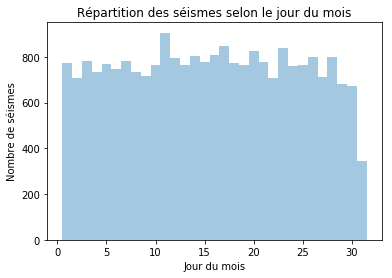

In [31]:
# Your turn! Plot the days of the month from your
# earthquake dataset and make sure they make sense.
day_of_month_earthquakes = day_of_month_earthquakes.dropna()

# Bornes centrées sur les entiers : une barre par jour, de 1 à 31
ax = sns.distplot(day_of_month_earthquakes, kde=False, bins=np.arange(1, 33) - 0.5)
ax.set_title("Répartition des séismes selon le jour du mois")
ax.set_xlabel("Jour du mois")
ax.set_ylabel("Nombre de séismes")

**Réponse :** la répartition est globalement assez plate de 1 à 30 et la baisse en fin de mois est en partie attendue : le 31 n'existe que dans 7 mois, et le 30 dans 11. Le 11 paraît nettement surreprésenté ; le 31 semble au contraire plus rare que ce que la seule structure du calendrier laisserait attendre. Le calcul ci-dessous compare les effectifs observés aux effectifs calendaires attendus et examine les écarts dans les **deux sens**.

In [32]:
# Bonus : test du khi-deux d'adéquation à une répartition « uniforme » des jours.
# Les fréquences attendues tiennent compte du calendrier : les jours 1 à 28 existent
# dans 12 mois, le 29 dans 11,25 mois en moyenne (années bissextiles), le 30 dans 11, le 31 dans 7.
from scipy import stats

months_with_day = np.array([12] * 28 + [11.25, 11, 7])
observed = day_of_month_earthquakes.value_counts().reindex(range(1, 32), fill_value=0).values
expected = observed.sum() * months_with_day / months_with_day.sum()

chi2, p_value = stats.chisquare(observed, f_exp=expected)
print(f"Khi-deux : {chi2:.1f} (30 degrés de liberté) ; p-valeur nominale : {p_value:.3g}")

# Jours les plus en écart par rapport à l'attendu (résidus standardisés)
# Résidus de Pearson : leur somme des carrés redonne le khi-deux
pearson_residuals = pd.Series(
    (observed - expected) / np.sqrt(expected),
    index=range(1, 32)
)

# Résidus standardisés pour les comparaisons individuelles
expected_prob = expected / observed.sum()
residuals = pd.Series(
    (observed - expected) / np.sqrt(expected * (1 - expected_prob)),
    index=range(1, 32)
)

print("\nJours les plus en écart, en valeur absolue (résidu standardisé) :")
order = residuals.abs().sort_values(ascending=False).index
print(residuals.reindex(order).head(5).round(2))

Khi-deux : 100.7 (30 degrés de liberté) ; p-valeur nominale : 1.46e-09

Jours les plus en écart, en valeur absolue (résidu standardisé) :
11    4.98
31   -4.90
17    2.89
23    2.52
22   -2.35
dtype: float64


In [33]:
# Quelles dates expliquent l'excès du 11 du mois ?
day_11 = earthquakes.loc[earthquakes['date_parsed'].dt.day == 11, 'date_parsed']
print("Dates les plus chargées parmi les « 11 » :")
print(day_11.value_counts().head(3))

Dates les plus chargées parmi les « 11 » :
2011-03-11    128
2012-04-11     12
2009-02-11     10
Name: date_parsed, dtype: int64


**Interprétation du calcul.** Sous un modèle où les séismes seraient des observations indépendantes et où chaque date du calendrier aurait le même taux moyen, l'effectif attendu pour le jour $j$ est proportionnel au nombre $m_j$ de mois qui contiennent ce jour :
$$E_j = N \cdot \frac{m_j}{365{,}25}, \qquad \chi^2 = \sum_{j=1}^{31} \frac{(O_j - E_j)^2}{E_j}.$$

Le calcul donne $\chi^2 = 100{,}7$ pour 30 degrés de liberté. **La p-valeur $1{,}46 \times 10^{-9}$ est seulement nominale ici**, car l'hypothèse d'indépendance est violée par les séquences de répliques ; elle ne doit donc pas être interprétée comme une p-valeur correctement calibrée pour ce catalogue.

**Quels jours s'écartent le plus ?** Pour les comparaisons individuelles, on utilise les résidus standardisés
$$
r_j^* =
\frac{O_j-E_j}
{\sqrt{E_j(1-p_j)}},
\qquad
p_j=\frac{E_j}{N}.
$$

Les deux écarts principaux sont le **11**, en excès ($r^*=4{,}98$), et le **31**, en déficit ($r^*=-4{,}90$). Le 17 ($r^*=2{,}89$), le 23 ($r^*=2{,}52$) et le 22 ($r^*=-2{,}35$) restent sous le seuil de Bonferroni bilatéral
$$
z_{1-0{,}05/62} \approx 3{,}15.
$$

Bonferroni contrôle la multiplicité sans exiger l'indépendance entre les 31 comparaisons ; le problème ici est en amont : la dépendance entre les séismes invalide le modèle multinomial et donc la calibration nominale des résidus.

**Explication de l'excès du 11.** La cellule précédente montre qu'une grande partie de cet excès vient du **11 mars 2011**, jour du séisme de Tōhoku au Japon : le catalogue compte **128 événements** ce jour-là, choc principal compris, alors qu'aucune autre date tombant un 11 n'en compte plus de 12. Cela illustre directement la dépendance temporelle due aux répliques.

Le **déficit du 31** n'est en revanche pas expliqué par cet épisode et doit être examiné séparément avant d'attribuer l'ensemble de l'écart au phénomène de répliques.

Après un grand séisme, le taux de répliques décroît typiquement selon la **loi d'Omori modifiée** (Omori-Utsu) :
$$
n(t)=\frac{K}{(c+t)^p},
\qquad p\approx1.
$$

Pour étudier rigoureusement la répartition des séismes principaux, il faudrait utiliser un modèle temporel adapté ou une procédure de *declustering*. Le test de Pearson naïf sert ici surtout de diagnostic descriptif.

And that's it for today! If you have any questions, be sure to post them in the comments below or [on the forums](https://www.kaggle.com/questions-and-answers). 

Remember that your notebook is private by default, and in order to share it with other people or ask for help with it, you'll need to make it public. First, you'll need to save a version of your notebook that shows your current work by hitting the "Commit & Run" button. (Your work is saved automatically, but versioning your work lets you go back and look at what it was like at the point you saved it. It also lets you share a nice compiled notebook instead of just the raw code.) Then, once your notebook is finished running, you can go to the Settings tab in the panel to the left (you may have to expand it by hitting the [<] button next to the "Commit & Run" button) and setting the "Visibility" dropdown to "Public".

# More practice!
___

If you're interested in graphing time series, [check out this Learn tutorial](https://www.kaggle.com/residentmario/time-series-plotting-optional).

You can also look into passing columns that you know have dates in them  the `parse_dates` argument in `read_csv`. (The documention [is here](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html).) Do note that this method can be very slow, but depending on your needs it may sometimes be handy to use.

For an extra challenge, you can try try parsing the column `Last Known Eruption` from the `volcanos` dataframe. This column contains a mixture of text ("Unknown") and years both before the common era (BCE, also known as BC) and in the common era (CE, also known as AD).

In [34]:
volcanos['Last Known Eruption'].sample(5)

764     Unknown
1069    1996 CE
34      1855 CE
489     2016 CE
9       1302 CE
Name: Last Known Eruption, dtype: object

In [35]:
# Bonus (défi « More practice ») : analyse de la colonne « Last Known Eruption »
eruption = volcanos['Last Known Eruption']
print("Valeurs les plus fréquentes :")
print(eruption.value_counts().head())

# Formats attendus : « <année> CE », « <année> BCE » ou « Unknown »
parts = eruption.str.extract(r'^(\d+)\s*(BCE|CE)$', expand=True)
parts.columns = ['year', 'era']
year = pd.to_numeric(parts['year'], errors='coerce')

# Numérotation astronomique : n BCE → 1 − n (le calendrier historique n'a pas d'année 0)
volcanos['last_eruption_year'] = np.where(parts['era'] == 'BCE', 1 - year, year)

n_unknown = (eruption == 'Unknown').sum()
n_unparsed = volcanos['last_eruption_year'].isnull().sum() - n_unknown
print(f"\nValeurs « Unknown » : {n_unknown}")
print(f"Valeurs dans un autre format (non converties) : {n_unparsed}")
print(f"Plage des années : {volcanos['last_eruption_year'].min():.0f} → {volcanos['last_eruption_year'].max():.0f}")

# Pourquoi on ne peut pas utiliser datetime64 ici
print(f"\nLimites de pd.Timestamp : {pd.Timestamp.min.year} → {pd.Timestamp.max.year}")
n_out_of_bounds = (volcanos['last_eruption_year'] < pd.Timestamp.min.year).sum()
print(f"Éruptions antérieures à {pd.Timestamp.min.year} (non représentables en datetime64) : {n_out_of_bounds}")

Valeurs les plus fréquentes :
Unknown    637
2016 CE     68
2015 CE     21
2014 CE     14
2012 CE     13
Name: Last Known Eruption, dtype: int64

Valeurs « Unknown » : 637
Valeurs dans un autre format (non converties) : 0
Plage des années : -10449 → 2016

Limites de pd.Timestamp : 1677 → 2262
Éruptions antérieures à 1677 (non représentables en datetime64) : 302


**Résultats du défi.** La colonne `Last Known Eruption` contient trois formes de valeurs : `Unknown` (637 volcans), `<année> CE` et `<année> BCE`. Toutes les valeurs datées ont été converties, sans exception.

**Pourquoi pas `datetime64` ?** Les années vont de **10 450 av. J.-C. à 2016**, et **302 éruptions** sont antérieures à 1677. Une éruption datée de 1677 pourrait aussi être hors bornes, puisque `pd.Timestamp.min` correspond au 21 septembre 1677. Une conversion en dates pandas aurait donc échoué ou produit des valeurs manquantes. On stocke plutôt une **année entière signée**.

**Numérotation astronomique.** Le calendrier historique passe de l'an 1 av. J.-C. à l'an 1 apr. J.-C. sans an 0. Pour que les soustractions donnent des durées exactes, on utilise la convention des astronomes :
$$n \text{ BCE} \;\longmapsto\; 1 - n, \qquad \text{donc } 1 \text{ BCE} \mapsto 0 \text{ et } 10\,450 \text{ BCE} \mapsto -10\,449.$$
L'écart entre 1 BCE et 1 CE vaut alors bien $1 - 0 = 1$ an.

**Alternative.** NumPy permet aussi des dates à l'unité « année » (`np.datetime64('…', 'Y')`), dont l'intervalle représentable est immense : côté NumPy, le compromis entre précision et étendue est un choix d'unité. Mais les versions de pandas utilisées ici n'acceptent que la nanoseconde dans une `Series` ou un `DataFrame`, d'où le recours à un entier.

## Synthèse

| Étape | Constat | Choix et justification |
|---|---|---|
| Type initial | `Date` est de type `object` (chaînes) | La conversion est indispensable avant tout calcul calendaire |
| Formats | 2 formats : `MM/JJ/AAAA` et 3 lignes en ISO 8601 | Format explicite + `errors='coerce'` pour isoler les exceptions, plutôt qu'une inférence silencieuse |
| Contrôle | Jours de 1 à 31, dont des valeurs supérieures à 12 | Exclut une inversion **globale** jour/mois ; les dates ambiguës doivent encore être contrôlées |
| Répartition des jours | $\chi^2_{30} = 100{,}7$, p-valeur nominale $\approx 1{,}46 \times 10^{-9}$ | Le 11 est en excès ($r^*=4{,}98$) et le 31 en déficit ($r^*=-4{,}90$) ; la dépendance entre séismes, notamment à cause des répliques, empêche d'interpréter naïvement la p-valeur |
| Volcans | Années de −10 449 à 2016, hors des bornes de `datetime64[ns]` | Années entières en numérotation astronomique |

**À retenir :** une conversion de dates se **vérifie** (types, plages, distributions). Un écart statistique peut signaler une erreur de données ou un phénomène réel, mais son interprétation doit respecter les hypothèses du modèle utilisé.